# ML2 Assignment #2, Task 2: Kernels - Formula1 edition

**Janin Jankovski, Florian Robrecht, Anna Hartmann**

---

**Dataset:** F1 Dataset(Kaggle) https://www.kaggle.com/datasets/jtrotman/formula-1-race-data?select=races.csv

**Pipeline**

  1: Fetch the data<br>
2: Data processing<br>
3: Data visualization results<br>
4: Model traing<br>
5: Take-home message


In [ ]:
# load libraries

# general
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import time

# kernel
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    f1_score, recall_score, precision_score, accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.metrics import f1_score, recall_score

# warnings
import warnings
warnings.filterwarnings("ignore")

### 1. Fetch the data

**Kaggle Formula 1 Dataset**: The dataset covers 1,125 races across 75 seasons from 1950 to 2024 and includes 39 features. For this analysis, 13 pre-race features were selected for modeling.

The target is binary classification: whether a driver finished in the top 3 (`podium`). 

In [ ]:
# Load data

path = kagglehub.dataset_download("rohanrao/formula-1-world-championship-1950-2020")

results = pd.read_csv(os.path.join(path, "results.csv"), na_values="\\N")
races = pd.read_csv(os.path.join(path, "races.csv"), na_values="\\N")
drivers = pd.read_csv(os.path.join(path, "drivers.csv"), na_values="\\N")
constructors = pd.read_csv(os.path.join(path, "constructors.csv"), na_values="\\N")
qualifying = pd.read_csv(os.path.join(path, "qualifying.csv"), na_values="\\N")
circuits = pd.read_csv(os.path.join(path, "circuits.csv"), na_values="\\N")

# merge tables
df = (
    results
    .merge(
        races[['raceId', 'year', 'round', 'circuitId', 'date']],
        on='raceId',
        how='left'
    )
    .merge(
        drivers[['driverId', 'forename', 'surname', 'dob', 'nationality']],
        on='driverId',
        how='left'
    )
    .merge(
        constructors[['constructorId', 'name', 'nationality']],
        on='constructorId',
        how='left',
        suffixes=('', '_constructor')
    )
    .merge(
        qualifying[['raceId', 'driverId', 'position']],
        on=['raceId', 'driverId'],
        how='left'
    )
    .merge(
        circuits[['circuitId', 'name', 'location', 'country']],
        on='circuitId',
        how='left',
        suffixes=('', '_circuit')
    )
)

# rename columns
df = df.rename(columns={
    'name': 'constructor_name',
    'name_circuit': 'circuit_name',
    'nationality': 'driver_nationality',
    'nationality_constructor': 'constructor_nationality',
    'position_y': 'qualifying_position'
})

# create target variable: podium finish (1 if positionOrder <= 3, else 0)
df['podium'] = (df['positionOrder'] <= 3).astype(int)

# basic cleaning
numeric_cols = [
    'grid', 'positionOrder', 'year', 'round', 'qualifying_position'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['dob'] = pd.to_datetime(df['dob'], errors='coerce')  # date of birth

100%|██████████| 6.28M/6.28M [00:01<00:00, 5.03MB/s]

Extracting files...


### 2. Data processing

Create pre-race features; subset data to target and pre-race features. 

In [ ]:
# create pre-race features
df['age'] = df['year'] - df['dob'].dt.year                         # driver's age in race year
df['driver_name'] = df['forename'] + ' ' + df['surname']           # full driver name
df['pole_position'] = (df['grid'] == 1).astype(int)                # 1 if driver started from qualifying P1
df['front_row'] = (df['grid'] <= 2).astype(int)                    # 1 if driver started in top 2
df['top3_start'] = (df['grid'] <= 3).astype(int)                   # 1 if driver started in top 3

# create clean modeling dataframe with only pre-race information
df_model = df[[
    'podium',                    # target: 1 if podium finish, 0 otherwise
    'grid',                      # starting grid position
    'year',                      # season year
    'round',                     # race round within season
    'age',                       # driver age
    'pole_position',             # binary: qualified first
    'front_row',                 # binary: qualified top 2
    'top3_start',                # binary: qualified top 3
    'driver_nationality',        # driver nationality
    'constructor_name',          # team / constructor
    'constructor_nationality',   # constructor nationality
    'circuit_name',              # track name
    'location',                  # city / location of circuit
    'country'                    # country of circuit
]].copy()

# final checks
print("Final shape:", df.shape)
print("Model shape:", df_model.shape)

counts = df_model['podium'].value_counts()
proportions = df_model['podium'].value_counts(normalize=True)

summary = pd.DataFrame({
    'count': counts,
    'proportion': proportions
})

display(summary)

print("\nMissing values in df_model:")
print(df_model.isna().sum().sort_values(ascending=False))

print("\nPreview of df_model:")
display(df_model.head())

Final shape: (26759, 38)
Model shape: (26759, 14)


,count,proportion
podium,,
0,23362,0.873052
1,3397,0.126948



Missing values in df_model:
podium                     0
grid                       0
year                       0
round                      0
age                        0
pole_position              0
front_row                  0
top3_start                 0
driver_nationality         0
constructor_name           0
constructor_nationality    0
circuit_name               0
location                   0
country                    0
dtype: int64

Preview of df_model:


,podium,grid,year,round,age,pole_position,front_row,top3_start,driver_nationality,constructor_name,constructor_nationality,circuit_name,location,country
0,1,1,2008,1,23,1,1,1,British,McLaren,British,Albert Park Grand Prix Circuit,Melbourne,Australia
1,1,5,2008,1,31,0,0,0,German,BMW Sauber,German,Albert Park Grand Prix Circuit,Melbourne,Australia
2,1,7,2008,1,23,0,0,0,German,Williams,British,Albert Park Grand Prix Circuit,Melbourne,Australia
3,0,11,2008,1,27,0,0,0,Spanish,Renault,French,Albert Park Grand Prix Circuit,Melbourne,Australia
4,0,3,2008,1,27,0,0,1,Finnish,McLaren,British,Albert Park Grand Prix Circuit,Melbourne,Australia


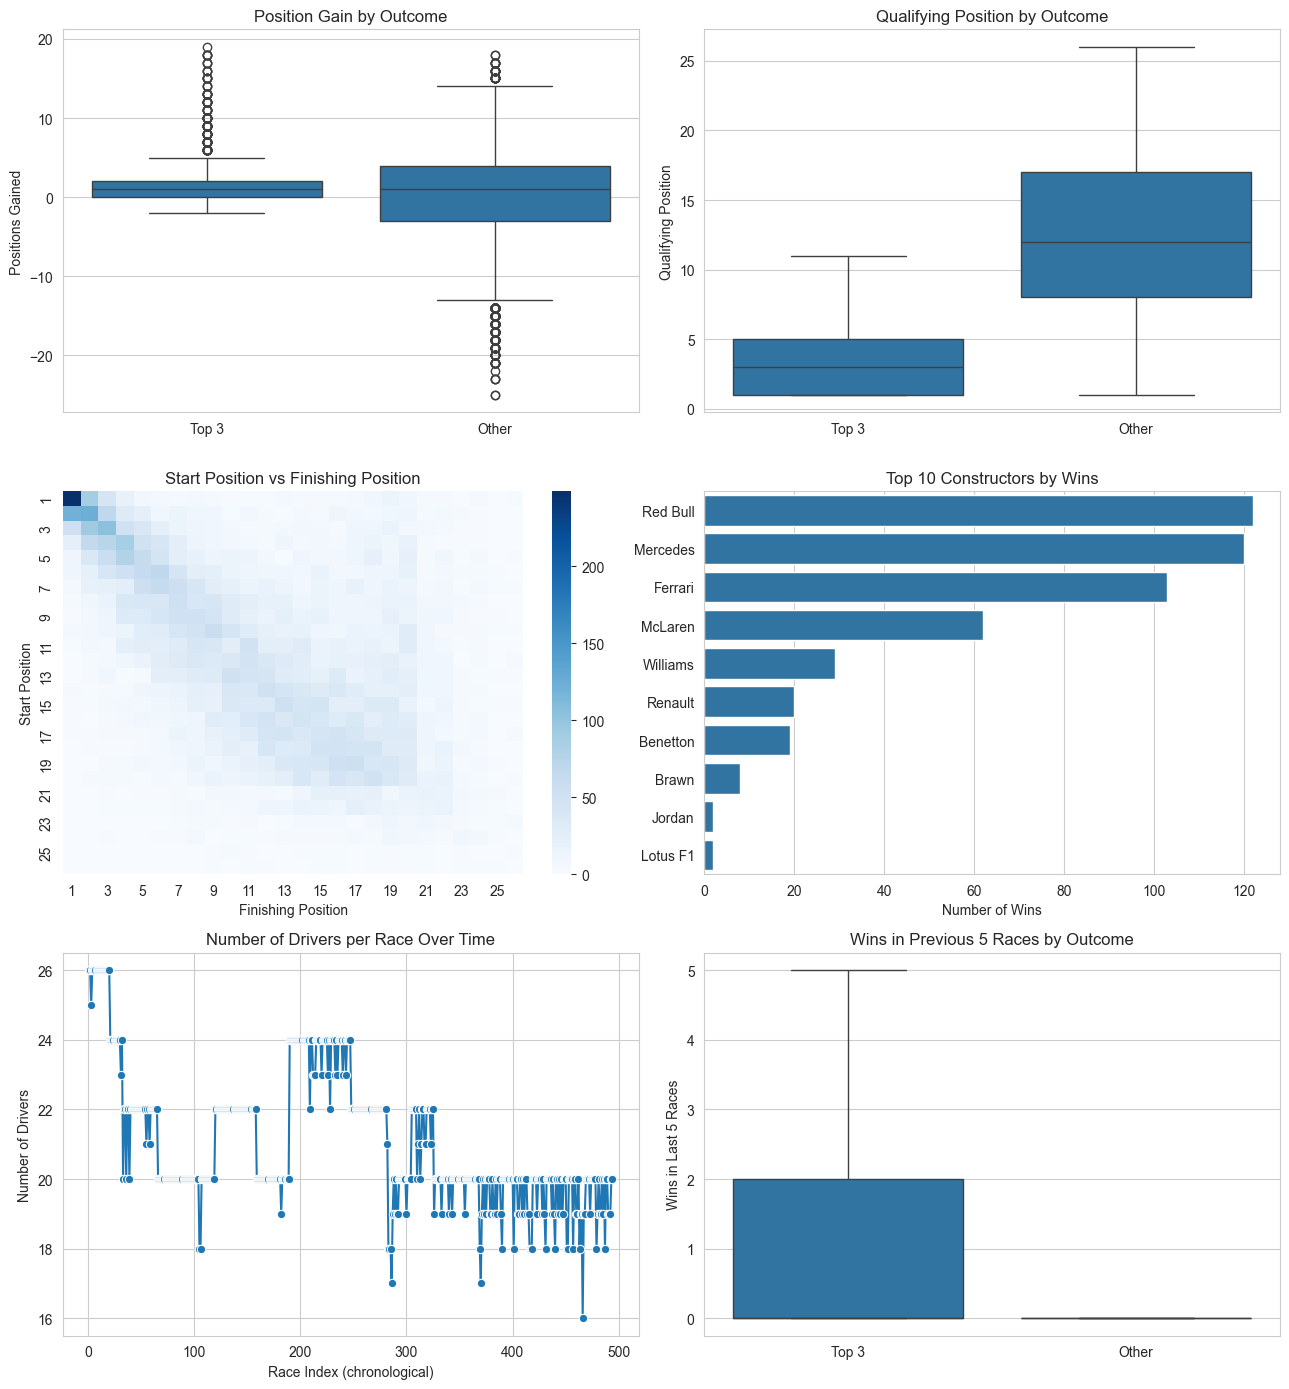

In [ ]:
sns.set_style("whitegrid")

# clean copy
df_eda = df.copy()

# numeric conversion
df_eda['grid'] = pd.to_numeric(df_eda['grid'], errors='coerce')
df_eda['qualifying_position'] = pd.to_numeric(df_eda['qualifying_position'], errors='coerce')
df_eda['positionOrder'] = pd.to_numeric(df_eda['positionOrder'], errors='coerce')
df_eda['year'] = pd.to_numeric(df_eda['year'], errors='coerce')
df_eda['round'] = pd.to_numeric(df_eda['round'], errors='coerce')

# drop missing values needed for plots
df_eda = df_eda.dropna(subset=[
    'grid', 'qualifying_position', 'positionOrder',
    'constructor_name', 'driverId', 'year', 'round'
])

# remove invalid grid values (0 = pit lane / no normal grid start)
df_eda = df_eda[df_eda['grid'] > 0]

# sort chronologically
df_eda = df_eda.sort_values(['driverId', 'year', 'round']).reset_index(drop=True)

# create labels and features
df_eda['top3'] = np.where(df_eda['positionOrder'] <= 3, 'Top 3', 'Other')
df_eda['position_gain'] = df_eda['qualifying_position'] - df_eda['positionOrder']  # positive = gained places
df_eda['win'] = (df_eda['positionOrder'] == 1).astype(int)

# wins in previous 5 races (strictly pre-race because of shift)
df_eda['wins_last_5'] = (
    df_eda.groupby('driverId')['win']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum())
)

# drivers per race over time
drivers_per_race = (
    df_eda.groupby(['year', 'round'])['driverId']
    .nunique()
    .reset_index(name='num_drivers')
    .sort_values(['year', 'round'])
    .reset_index(drop=True)
)

drivers_per_race['race_index'] = range(1, len(drivers_per_race) + 1)

fig, axes = plt.subplots(3, 2, figsize=(13, 14))

# 1. Position gain by outcome
sns.boxplot(
    data=df_eda,
    x='top3',
    y='position_gain',
    ax=axes[0, 0],
    showfliers=True
)
axes[0, 0].set_title("Position Gain by Outcome")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Positions Gained")

# 2. Qualifying position by outcome
sns.boxplot(
    data=df_eda,
    x='top3',
    y='qualifying_position',
    ax=axes[0, 1],
    showfliers=False
)
axes[0, 1].set_title("Qualifying Position by Outcome")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Qualifying Position")

# 3. Start position vs finishing position
heatmap_data = df_eda.pivot_table(
    index='grid',
    columns='positionOrder',
    aggfunc='size',
    fill_value=0
)

sns.heatmap(
    heatmap_data,
    cmap='Blues',
    ax=axes[1, 0]
)
axes[1, 0].set_title("Start Position vs Finishing Position")
axes[1, 0].set_xlabel("Finishing Position")
axes[1, 0].set_ylabel("Start Position")

# 4. Top 10 constructors by wins
wins = (
    df_eda[df_eda['positionOrder'] == 1]
    .groupby('constructor_name')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

sns.barplot(
    x=wins.values,
    y=wins.index,
    ax=axes[1, 1]
)
axes[1, 1].set_title(f"Top 10 Constructors by Wins")
axes[1, 1].set_xlabel("Number of Wins")
axes[1, 1].set_ylabel("")

# 5. Number of drivers per race over time
sns.lineplot(
    data=drivers_per_race,
    x='race_index',
    y='num_drivers',
    marker='o',
    ax=axes[2, 0]
)
axes[2, 0].set_title("Number of Drivers per Race Over Time")
axes[2, 0].set_xlabel("Race Index (chronological)")
axes[2, 0].set_ylabel("Number of Drivers")

# 6. Wins in previous 5 races by outcome
sns.boxplot(
    data=df_eda,
    x='top3',
    y='wins_last_5',
    ax=axes[2, 1],
    showfliers=False
)
axes[2, 1].set_title("Wins in Previous 5 Races by Outcome")
axes[2, 1].set_xlabel("")
axes[2, 1].set_ylabel("Wins in Last 5 Races")

plt.tight_layout()
plt.show()

### 3. Data visualization results

*1. Position Gain by Outcome*  
Podium drivers show small, consistent gains, while others are much more volatile with large gains and losses.

*2. Qualifying Position by Outcome*<br>
Drivers who finish in the top 3 typically start from very strong qualifying positions, making it a key predictor.

*3. Start Position vs Finishing Position*  
Drivers tend to finish close to where they start, indicating limited movement during races.

*4. Top 10 Constructors by Wins*  
A few top teams dominate race wins, highlighting the importance of constructor strength.

*5. Number of Drivers per Race Over Time*  
The number of drivers per race has decreased and stabilized around ~20 in modern Formula 1.

*6. Wins in Previous 5 Races by Outcome*  
Drivers with recent wins are more likely to finish in the top 3, showing the importance of current form.

### 4. Model training

**Evaluation Metrics**

The target variable is highly imbalanced (~13% podium finishes). Accuracy can be misleading (you could predict “no podium” always and still be ~87% correct).
We therefore compare accuracy and the F1 score:

$F_1 = 2 \cdot \frac{\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}$

This balances precision and recall, ensuring that both false positives and false negatives are penalized.  
In this context, correctly identifying podium drivers while avoiding incorrect predictions is equally important.

In simple terms: 
Precision = “if I predict podium, how often am I right?”
Recall = “how many real podiums did I find?”

F1 balances both → we don’t want too many wrong guesses or missed podiums.

---

**Kernel Choice: RBF vs Polynomial**

We compare two nonlinear kernels within the Support Vector Machine framework.

The polynomial kernel:  
$K(x, x') = (\gamma \cdot x \cdot x' + r)^d$

captures explicit feature interactions up to degree $d$, but higher degrees often lead to overfitting as it gets complex quickly. 

The RBF (Gaussian) kernel:  
$K(x, x') = \exp(-\gamma \|x - x'\|^2)$

measures similarity based on distance.

In practice, the RBF kernel performs better, as it captures complex nonlinear relationships without requiring manual specification of interactions.

---

**Hyperparameter Interpretation**

We tune two key parameters using GridSearchCV:

- $C$: controls the trade-off between margin maximization and classification error  (how much we punish mistakes)
- $\gamma$: controls the locality of the decision boundary (how “local” the decision is)

Formally, SVM solves:

$\min_{w,b} \frac{1}{2} \|w\|^2 + C \sum_i \xi_i$

A small C allows more mistakes → simpler model (can miss patterns), while a large C tries to avoid mistakes → more complex model (can overfit).  
a small γ gives smooth, general patterns, while a large γ makes very detailed, local decisions.

---

**Time-Based Rolling Window Evaluation**

We use an expanding rolling window: train on past seasons and test on the next season.

This avoids data leakage and reflects a real-world setting where only historical data is available.  
It also allows us to observe how model performance evolves as more training data becomes available.
You train exactly 45 models per year, and with 65 test years (1960–2024) this results in 2,925 models in total.

In [ ]:
# F1 Hyperparameter optimization with rolling window approach for RBF and polynomial kernel with grid search

# sort data
df_model = df_model.sort_values(['year', 'round']).reset_index(drop=True)
years = sorted(df_model['year'].unique())

min_years = 10
checkpoint_file = "kernel_results.csv"

# load checkpoint if exists
if os.path.exists(checkpoint_file):
    kernel_results_df = pd.read_csv(checkpoint_file)
    completed_years = set(kernel_results_df['year'])
    results = kernel_results_df.to_dict(orient='records')
else:
    completed_years = set()
    results = []

total_start = time.time()

for i in range(min_years, len(years)):
    iter_start = time.time()

    train_years = years[:i]
    test_year = years[i]

    # skip already processed years
    if test_year in completed_years:
        continue

    train_df = df_model[df_model['year'].isin(train_years)]
    test_df = df_model[df_model['year'] == test_year]

    X_train = train_df.drop(columns='podium')
    y_train = train_df['podium']

    X_test = test_df.drop(columns='podium')
    y_test = test_df['podium']

    # one-hot encoding
    X_train = pd.get_dummies(X_train)
    X_test = pd.get_dummies(X_test)

    # align columns
    X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

    # scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    print(f"\nTrain: {train_years[0]}–{train_years[-1]} | Test: {test_year}")

    # RBF
    param_grid_rbf = {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 0.01, 0.1]
    }

    grid_rbf = GridSearchCV(
        SVC(kernel='rbf', class_weight='balanced'),
        param_grid_rbf,
        scoring='f1',
        cv=3,
        n_jobs=-1
    )

    grid_rbf.fit(X_train, y_train)
    best_rbf = grid_rbf.best_estimator_
    y_pred_rbf = best_rbf.predict(X_test)

    rbf_f1 = f1_score(y_test, y_pred_rbf)
    rbf_recall = recall_score(y_test, y_pred_rbf)
    rbf_precision = precision_score(y_test, y_pred_rbf, zero_division=0)
    rbf_acc = accuracy_score(y_test, y_pred_rbf)

    print(f"RBF → F1: {rbf_f1:.3f} | Recall: {rbf_recall:.3f} | Precision: {rbf_precision:.3f} | Acc: {rbf_acc:.3f}")

    # Polynomial
    param_grid_poly = {
        'C': [0.1, 1, 10],
        'degree': [2, 3],
        'gamma': ['scale'] # Scale means gamma is automatically set to number of 1/features×data variance, so it adapts to your dataset.
                           # The model looks at how spread out your data is and then automatically picks a gamma that gives a “reasonable” level of flexibility.
                           # If your data is very spread out → gamma gets smaller (smoother model)
                           # If your data is tight → gamma gets bigger (more detailed model)
    }

    grid_poly = GridSearchCV(
        SVC(kernel='poly', class_weight='balanced'),
        param_grid_poly,
        scoring='f1',
        cv=3,
        n_jobs=-1
    )

    grid_poly.fit(X_train, y_train)
    best_poly = grid_poly.best_estimator_
    y_pred_poly = best_poly.predict(X_test)

    poly_f1 = f1_score(y_test, y_pred_poly)
    poly_recall = recall_score(y_test, y_pred_poly)
    poly_precision = precision_score(y_test, y_pred_poly, zero_division=0)
    poly_acc = accuracy_score(y_test, y_pred_poly)

    print(f"Poly → F1: {poly_f1:.3f} | Recall: {poly_recall:.3f} | Precision: {poly_precision:.3f} | Acc: {poly_acc:.3f}")

    # runtime
    iter_time = time.time() - iter_start
    print(f"Iteration time: {iter_time:.2f} sec")

    # store results
    results.append({
        'year': test_year,

        # RBF test metrics
        'rbf_f1': rbf_f1,
        'rbf_recall': rbf_recall,
        'rbf_precision': rbf_precision,
        'rbf_acc': rbf_acc,
        # RBF hyperparameters
        'rbf_C': grid_rbf.best_params_['C'],
        'rbf_gamma': grid_rbf.best_params_['gamma'],
        'rbf_cv_f1': grid_rbf.best_score_,

        # Polynomial test metrics
        'poly_f1': poly_f1,
        'poly_recall': poly_recall,
        'poly_precision': poly_precision,
        'poly_acc': poly_acc,
        # Polynomial hyperparameters
        'poly_C': grid_poly.best_params_['C'],
        'poly_degree': grid_poly.best_params_['degree'],
        'poly_gamma': grid_poly.best_params_['gamma'],
        'poly_cv_f1': grid_poly.best_score_,

        # Meta
        'runtime_sec': iter_time,
        'n_train': len(train_df),
        'n_test': len(test_df)
    })

    completed_years.add(test_year)

    # save after each iteration
    kernel_results_df = pd.DataFrame(results).sort_values('year').reset_index(drop=True)
    kernel_results_df.to_csv(checkpoint_file, index=False)

# total runtime
total_time = time.time() - total_start
print(f"\nTOTAL RUNTIME: {total_time:.2f} sec")

kernel_results_df = pd.DataFrame(results).sort_values('year').reset_index(drop=True)
display(kernel_results_df.head())


TOTAL RUNTIME: 0.00 sec


,year,rbf_f1,rbf_recall,rbf_precision,rbf_acc,rbf_C,rbf_gamma,rbf_cv_f1,poly_f1,poly_recall,poly_precision,poly_acc,poly_C,poly_degree,poly_gamma,poly_cv_f1,runtime_sec,n_train,n_test
0,1960,0.270270,0.322581,0.232558,0.757848,0.1,scale,0.380558,0.316832,0.516129,0.228571,0.690583,1,2,scale,0.351363,13.442767,2007,223
1,1961,0.347826,0.666667,0.235294,0.727273,0.1,scale,0.366430,0.265060,0.458333,0.186441,0.722727,1,2,scale,0.316764,6.705152,2230,220
2,1962,0.307692,0.444444,0.235294,0.757848,0.1,scale,0.378484,0.236842,0.333333,0.183673,0.739910,10,3,scale,0.347818,16.346153,2450,223
3,1963,0.318182,0.466667,0.241379,0.763780,1.0,0.01,0.373720,0.285714,0.400000,0.222222,0.763780,10,3,scale,0.336897,18.938988,2673,254
4,1964,0.367347,0.600000,0.264706,0.700483,0.1,scale,0.363155,0.357143,0.500000,0.277778,0.739130,10,3,scale,0.313724,28.591108,2927,207


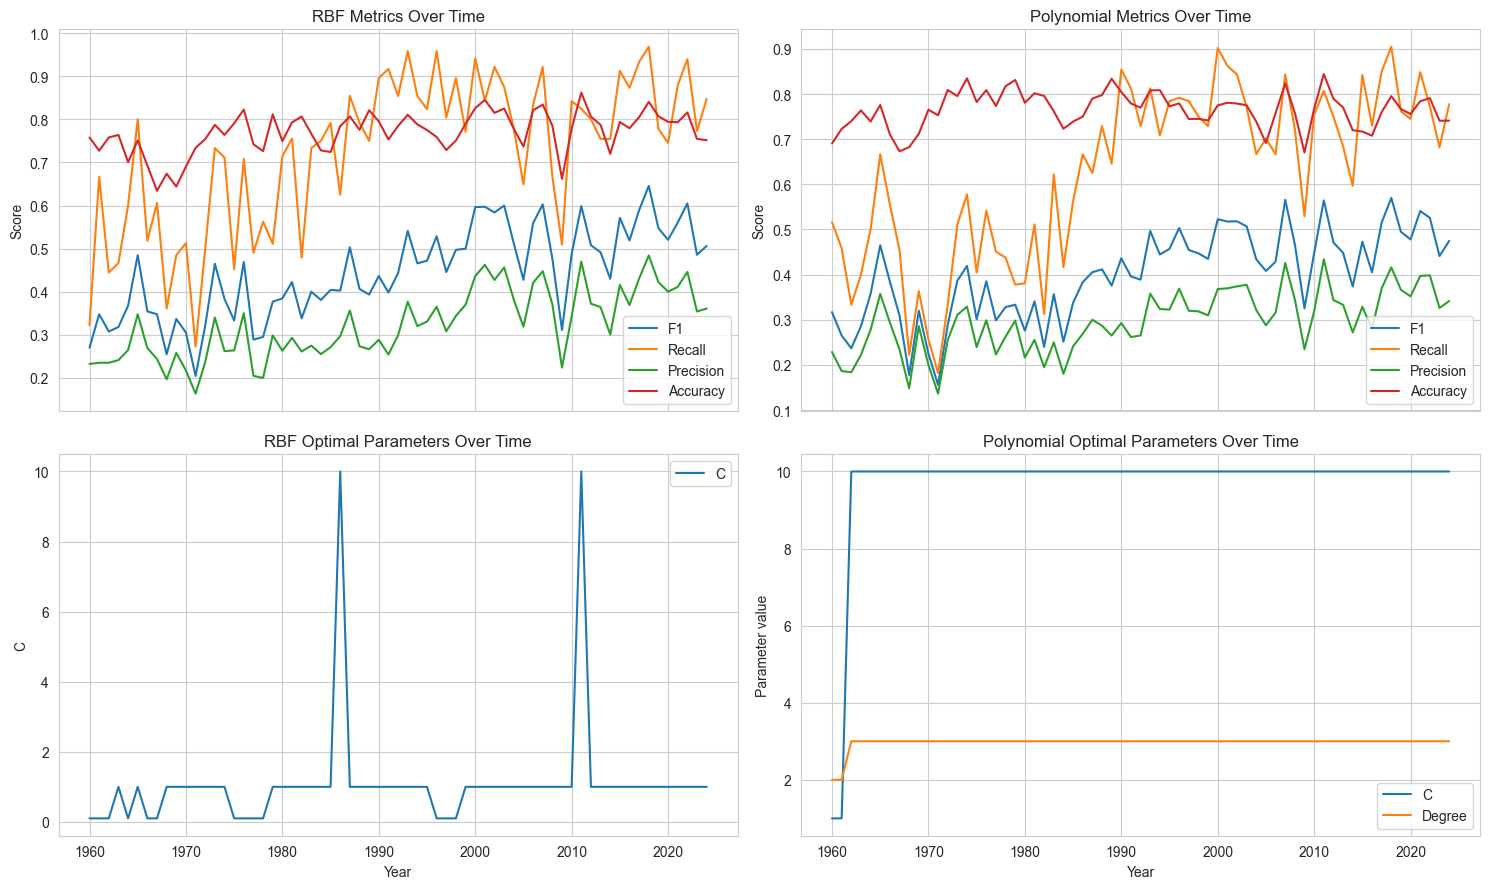

In [ ]:
# plot results: metrics and optimal parameters

fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex='col')

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

metrics = [
    ('f1', 'F1'),
    ('recall', 'Recall'),
    ('precision', 'Precision'),
    ('acc', 'Accuracy')
]

# RBF metrics
for i, (metric, label) in enumerate(metrics):
    axes[0, 0].plot(
        kernel_results_df['year'],
        kernel_results_df[f'rbf_{metric}'],
        label=label,
        color=colors[i]
    )

axes[0, 0].set_title('RBF Metrics Over Time')
axes[0, 0].set_ylabel('Score')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Polynomial metrics
for i, (metric, label) in enumerate(metrics):
    axes[0, 1].plot(
        kernel_results_df['year'],
        kernel_results_df[f'poly_{metric}'],
        label=label,
        color=colors[i]
    )

axes[0, 1].set_title('Polynomial Metrics Over Time')
axes[0, 1].set_ylabel('Score')
axes[0, 1].legend()
axes[0, 1].grid(True)

# RBF optimal parameters
axes[1, 0].plot(
    kernel_results_df['year'],
    kernel_results_df['rbf_C'],
    label='C',
    color=colors[0]
)

axes[1, 0].set_title('RBF Optimal Parameters Over Time')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('C')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Polynomial optimal parameters
axes[1, 1].plot(
    kernel_results_df['year'],
    kernel_results_df['poly_C'],
    label='C',
    color=colors[0]
)

axes[1, 1].plot(
    kernel_results_df['year'],
    kernel_results_df['poly_degree'],
    label='Degree',
    color=colors[1]
)

axes[1, 1].set_title('Polynomial Optimal Parameters Over Time')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Parameter value')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

Both models improve over time as more training data becomes available, with **F1, recall, and precision increasing steadily**.  
The **RBF model consistently performs better** and is more stable than the polynomial model.  

The difference likely comes from how the models learn.  
The RBF kernel groups similar observations and can adapt to complex, changing patterns in the data.  
The polynomial model relies on fixed feature interactions, which makes it less flexible.  

As a result, the polynomial model is more unstable and shows occasional drops in performance.  
This suggests that the underlying relationships in the data are better captured by **flexible, distance-based learning** rather than combinations of features.  

---

The hyperparameters help explain how **“strict” or “flexible”** the model is.  

For the RBF model, **$C$ is usually low** (around 0.1–1), meaning the model allows some mistakes and **stays relatively simple** and stable.  

However, there is one clear spike where $C$ becomes large.  
A high $C$ means the model tries very hard to fit the training data and avoid mistakes.  
This suggests that in that specific year, the model needed a more complex decision boundary to capture the patterns in the data.  
The fact that this spike happens only once shows that most of the time the data can be modeled with a simple structure. In that year, however, the data appears to be more irregular or harder to predict. 

For the polynomial model, **$C$ is almost always high** and the **degree is fixed at 3**.  
This means it constantly relies on a **more complex setup**, supporting the idea that it struggles to capture the data in a simple and stable way.

Top 5 RBF years (ordered): [2003, 2007, 2011, 2018, 2022]
Top 5 Polynomial years (ordered): [2007, 2011, 2018, 2021, 2022]


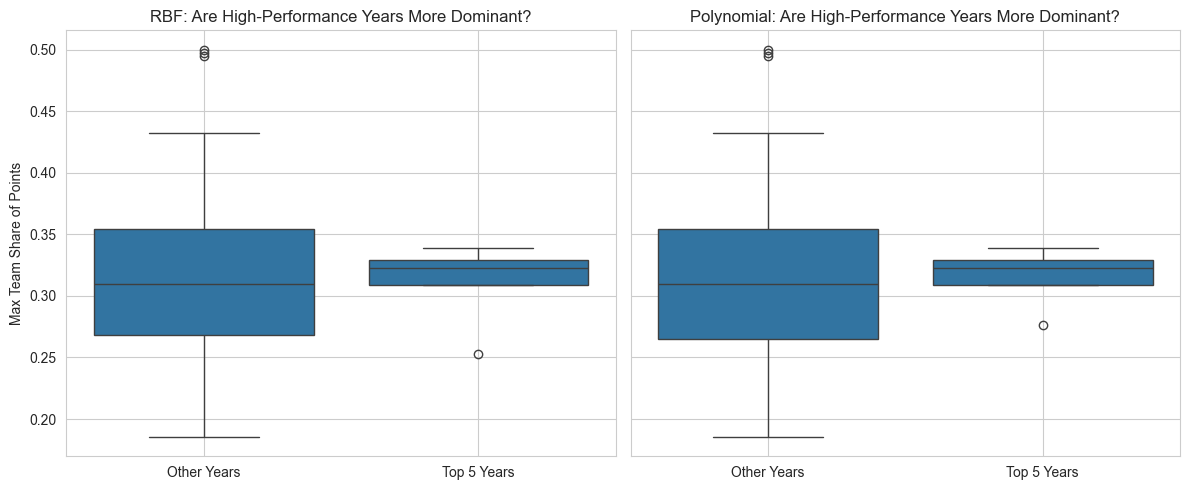

In [ ]:
# Why are the spikes in performance metrics occurring in certain years? Are those years more "dominant" in terms of team performance?

# get top 5 years for models f1 score
top_rbf = sorted(kernel_results_df.nlargest(5, 'rbf_f1')['year'].tolist())
top_poly = sorted(kernel_results_df.nlargest(5, 'poly_f1')['year'].tolist())

print(f"Top 5 RBF years (ordered): {top_rbf}")
print(f"Top 5 Polynomial years (ordered): {top_poly}")

# compute dominance (same as before)
dominance_list = []

for year in df['year'].unique():
    df_year = df[df['year'] == year]

    team_points = df_year.groupby('constructor_name')['points'].sum()
    shares = team_points / team_points.sum()
    max_share = shares.max()

    dominance_list.append({'year': year, 'max_share': max_share})

dominance_df = pd.DataFrame(dominance_list)

# merge
merged = kernel_results_df.merge(dominance_df, on='year')

# create groups for both models
merged['group_rbf'] = merged['year'].apply(
    lambda x: 'Top 5 Years' if x in top_rbf else 'Other Years'
)

merged['group_poly'] = merged['year'].apply(
    lambda x: 'Top 5 Years' if x in top_poly else 'Other Years'
)

# plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# RBF plot
sns.boxplot(x='group_rbf', y='max_share', data=merged, ax=axes[0])
axes[0].set_title('RBF: Are High-Performance Years More Dominant?')
axes[0].set_xlabel('')
axes[0].set_ylabel('Max Team Share of Points')
axes[0].grid(True)

# Polynomial plot
sns.boxplot(x='group_poly', y='max_share', data=merged, ax=axes[1])
axes[1].set_title('Polynomial: Are High-Performance Years More Dominant?')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Both models have their best F1 scores in the same years. <br>
These years also show higher team dominance, measured by a larger share of total points being concentrated in one or a few teams. <br>
This means the performance spikes come from the data: when a few teams consistently take most of the points, results become more predictable and easier to model. <br>

The dip around 2010, for example, can be explained by a rule change that made the season more unpredictable, along with the unexpected dominance of another team.

In [18]:
# Accuracy hyperparameter optimization with rolling window approach for RBF and polynomial kernel with grid search

# sort data
df_model = df_model.sort_values(['year', 'round']).reset_index(drop=True)
years = sorted(df_model['year'].unique())

min_years = 10
checkpoint_file = "kernel_results_accuracy.csv"

# load checkpoint if exists
if os.path.exists(checkpoint_file):
    kernel_results_accuracy = pd.read_csv(checkpoint_file)
    completed_years = set(kernel_results_accuracy['year'])
    results = kernel_results_accuracy.to_dict(orient='records')
else:
    completed_years = set()
    results = []

total_start = time.time()

for i in range(min_years, len(years)):
    iter_start = time.time()

    train_years = years[:i]
    test_year = years[i]

    # skip already processed years
    if test_year in completed_years:
        continue

    train_df = df_model[df_model['year'].isin(train_years)]
    test_df = df_model[df_model['year'] == test_year]

    X_train = train_df.drop(columns='podium')
    y_train = train_df['podium']

    X_test = test_df.drop(columns='podium')
    y_test = test_df['podium']

    # one-hot encoding
    X_train = pd.get_dummies(X_train)
    X_test = pd.get_dummies(X_test)

    # align columns
    X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

    # scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    print(f"\nTrain: {train_years[0]}–{train_years[-1]} | Test: {test_year}")

    # RBF
    param_grid_rbf = {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 0.01, 0.1]
    }

    grid_rbf = GridSearchCV(
        SVC(kernel='rbf', class_weight='balanced'),
        param_grid_rbf,
        scoring='accuracy',
        cv=3,
        n_jobs=-1
    )

    grid_rbf.fit(X_train, y_train)
    best_rbf = grid_rbf.best_estimator_
    y_pred_rbf = best_rbf.predict(X_test)

    rbf_f1 = f1_score(y_test, y_pred_rbf)
    rbf_recall = recall_score(y_test, y_pred_rbf)
    rbf_precision = precision_score(y_test, y_pred_rbf, zero_division=0)
    rbf_acc = accuracy_score(y_test, y_pred_rbf)

    print(f"RBF → F1: {rbf_f1:.3f} | Recall: {rbf_recall:.3f} | Precision: {rbf_precision:.3f} | Acc: {rbf_acc:.3f}")

    # Polynomial
    param_grid_poly = {
        'C': [0.1, 1, 10],
        'degree': [2, 3],
        'gamma': ['scale']
    }

    grid_poly = GridSearchCV(
        SVC(kernel='poly', class_weight='balanced'),
        param_grid_poly,
        scoring='accuracy',
        cv=3,
        n_jobs=-1
    )

    grid_poly.fit(X_train, y_train)
    best_poly = grid_poly.best_estimator_
    y_pred_poly = best_poly.predict(X_test)

    poly_f1 = f1_score(y_test, y_pred_poly)
    poly_recall = recall_score(y_test, y_pred_poly)
    poly_precision = precision_score(y_test, y_pred_poly, zero_division=0)
    poly_acc = accuracy_score(y_test, y_pred_poly)

    print(f"Poly → F1: {poly_f1:.3f} | Recall: {poly_recall:.3f} | Precision: {poly_precision:.3f} | Acc: {poly_acc:.3f}")

    # runtime
    iter_time = time.time() - iter_start
    print(f"Iteration time: {iter_time:.2f} sec")

    # store results
    results.append({
        'year': test_year,

        # RBF test metrics
        'rbf_f1': rbf_f1,
        'rbf_recall': rbf_recall,
        'rbf_precision': rbf_precision,
        'rbf_acc': rbf_acc,
        # RBF hyperparameters
        'rbf_C': grid_rbf.best_params_['C'],
        'rbf_gamma': grid_rbf.best_params_['gamma'],
        'rbf_cv_accuracy': grid_rbf.best_score_,

        # Polynomial test metrics
        'poly_f1': poly_f1,
        'poly_recall': poly_recall,
        'poly_precision': poly_precision,
        'poly_acc': poly_acc,
        # Polynomial hyperparameters
        'poly_C': grid_poly.best_params_['C'],
        'poly_degree': grid_poly.best_params_['degree'],
        'poly_gamma': grid_poly.best_params_['gamma'],
        'poly_cv_accuracy': grid_poly.best_score_,

        # Meta
        'runtime_sec': iter_time,
        'n_train': len(train_df),
        'n_test': len(test_df)
    })

    completed_years.add(test_year)

    # save after each iteration
    kernel_results_accuracy = pd.DataFrame(results).sort_values('year').reset_index(drop=True)
    kernel_results_accuracy.to_csv(checkpoint_file, index=False)

# total runtime
total_time = time.time() - total_start
print(f"\nTOTAL RUNTIME: {total_time:.2f} sec")

kernel_results_accuracy = pd.DataFrame(results).sort_values('year').reset_index(drop=True)
display(kernel_results_accuracy.head())


Train: 1950–2013 | Test: 2014
RBF → F1: 0.048 | Recall: 0.035 | Precision: 0.074 | Acc: 0.803
Poly → F1: 0.398 | Recall: 0.667 | Precision: 0.284 | Acc: 0.717
Iteration time: 777.28 sec

Train: 1950–2014 | Test: 2015
RBF → F1: 0.211 | Recall: 0.140 | Precision: 0.421 | Acc: 0.841
Poly → F1: 0.476 | Recall: 0.860 | Precision: 0.329 | Acc: 0.714
Iteration time: 817.35 sec

Train: 1950–2015 | Test: 2016
RBF → F1: 0.340 | Recall: 0.254 | Precision: 0.516 | Acc: 0.866
Poly → F1: 0.420 | Recall: 0.746 | Precision: 0.292 | Acc: 0.719
Iteration time: 822.34 sec

Train: 1950–2016 | Test: 2017
RBF → F1: 0.391 | Recall: 0.283 | Precision: 0.630 | Acc: 0.868
Poly → F1: 0.508 | Recall: 0.833 | Precision: 0.365 | Acc: 0.757
Iteration time: 851.09 sec

Train: 1950–2017 | Test: 2018
RBF → F1: 0.420 | Recall: 0.333 | Precision: 0.568 | Acc: 0.862
Poly → F1: 0.570 | Recall: 0.905 | Precision: 0.416 | Acc: 0.795
Iteration time: 883.08 sec

Train: 1950–2018 | Test: 2019
RBF → F1: 0.242 | Recall: 0.175 | 

,year,rbf_f1,rbf_recall,rbf_precision,rbf_acc,rbf_C,rbf_gamma,rbf_cv_accuracy,poly_f1,poly_recall,poly_precision,poly_acc,poly_C,poly_degree,poly_gamma,poly_cv_accuracy,runtime_sec,n_train,n_test
0,1960,0.153846,0.129032,0.190476,0.802691,1.0,0.1,0.816642,0.439024,0.580645,0.352941,0.793722,0.1,2,scale,0.858994,1.130714,2007,223
1,1961,0.105263,0.083333,0.142857,0.845455,10.0,0.1,0.812541,0.244898,0.250000,0.240000,0.831818,0.1,2,scale,0.854706,1.339844,2230,220
2,1962,0.285714,0.222222,0.400000,0.865471,10.0,0.1,0.828172,0.366667,0.407407,0.333333,0.829596,0.1,2,scale,0.826948,1.658918,2450,223
3,1963,0.212766,0.166667,0.294118,0.854331,10.0,0.1,0.837262,0.344828,0.500000,0.263158,0.775591,0.1,2,scale,0.809951,2.043656,2673,254
4,1964,0.264151,0.233333,0.304348,0.811594,10.0,0.1,0.842165,0.369565,0.566667,0.274194,0.719807,10.0,2,scale,0.742060,2.484017,2927,207


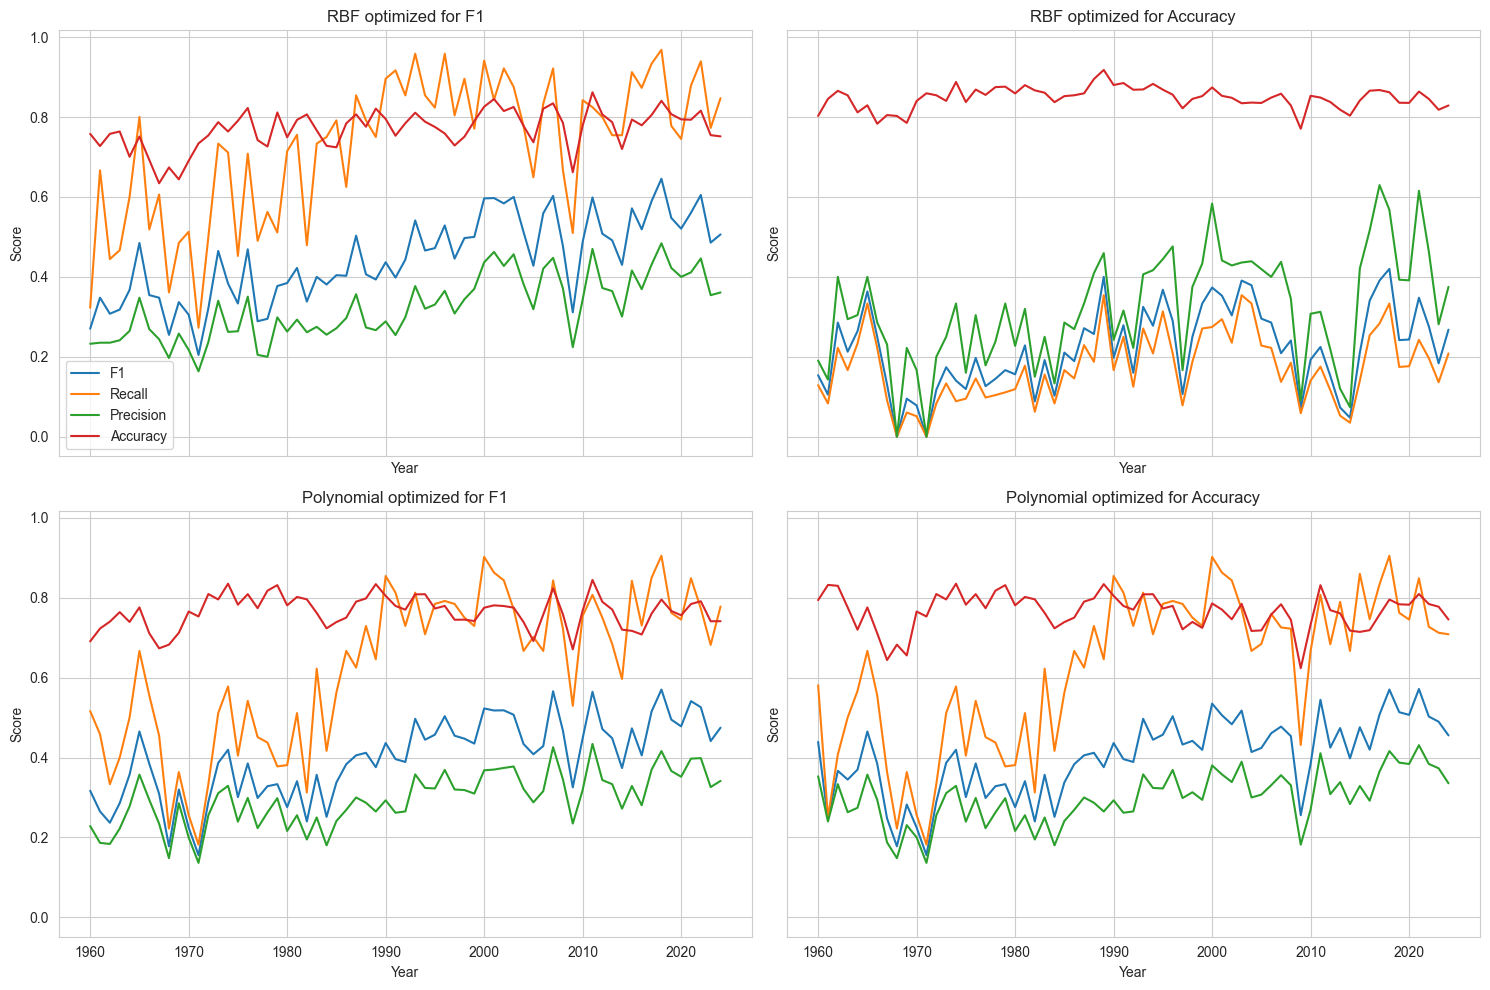

In [19]:
# compare F1-optimized and accuracy-optimized models

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True, sharey=True)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

metrics = [
    ('f1', 'F1'),
    ('recall', 'Recall'),
    ('precision', 'Precision'),
    ('acc', 'Accuracy')
]

plots = [
    (axes[0, 0], kernel_results_df, 'rbf', 'RBF optimized for F1'),
    (axes[0, 1], kernel_results_accuracy, 'rbf', 'RBF optimized for Accuracy'),
    (axes[1, 0], kernel_results_df, 'poly', 'Polynomial optimized for F1'),
    (axes[1, 1], kernel_results_accuracy, 'poly', 'Polynomial optimized for Accuracy')
]

for ax, data, model, title in plots:
    for i, (metric, label) in enumerate(metrics):
        ax.plot(
            data['year'],
            data[f'{model}_{metric}'],
            label=label,
            color=colors[i]
        )

    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.set_ylabel('Score')
    ax.grid(True)

axes[0, 0].legend()

plt.tight_layout()
plt.show()

When optimizing for accuracy, the model sacrifices balance between precision and recall. The model learns to just predict the dominant class, you can see that for both kernels: Accuracy stays high, but F1, recall, precision collapse. The effect is stronger for the RBF kernel because its higher flexibility allows it to better exploit the optimization objective, often overfitting to the majority class when optimizing for accuracy. The polynomial kernel is more constrained, so it is less sensitive to the choice of optimization metric.

## 5. Take-Home Message

**Initial Question:**  
How well can we predict whether a driver finishes on the podium using nonlinear SVMs, and which kernel (RBF vs polynomial) performs better over time?

---

### Findings

**1. Performance improves across all metrics over time**  
Using an expanding rolling window (training on past seasons and testing on the next), performance improves across all metrics over time.  
As more training data becomes available, the model learns more stable patterns, leading to consistent improvements in F1, recall, precision, and accuracy.

**2. RBF outperforms the polynomial kernel on average**  
Across most years, the RBF model achieves higher and more stable performance.  
This suggests that our dataset is better described by local, nonlinear patterns, which are captured more effectively through distance-based learning than through fixed feature interactions.

**3. Performance varies across seasons, with clear spikes in certain years**  
Some years show noticeably higher prediction performance.  
Both models achieve their highest F1 scores in the same years, and these years also exhibit higher team dominance, measured by a larger share of total points concentrated in a few teams.  
This indicates that performance spikes are driven by the structure of the data: when outcomes are more concentrated and predictable, models perform better.

**4. Kernel type vs optimization metrics:**
Both RBF and Polynomial kernels show the same pattern, the choice of optimization metric has a larger impact than the kernel itself. Optimizing for F1 performs better because it balances precision and recall, whereas accuracy can be misleading in imbalanced datasets and tends to favor the majority class. The polynomial kernel is less sensitive to the choice of optimization metric.